# Monte Carlo: Thailand's EV Race

Thailand has long been identified as the "Detroit of Asia," with Japanese automakers such as Toyota and Honda dominating the domestic vehicle industry. But Thailand's EV subsidies and 30@30 policy(which aims to increase production of local, 0 emission vehicles) have opened the door for Chinese EV firms such as BYD, MG, and Great Wall Motor.

This notebook simulates how different policy and macroeconomic scenarios could affect the future stock-price paths of two proxy firms:
- Toyota: Japanese incumbent automaker
- BYD: Chinese EV disruptor

Instead of using a basic Monte Carlo model, this notebook modifies the drift and volatility of each stock using Thailand-specific shocks:
1. EV subsidy strength or subsidy cliff
2. Household debt pressure
3. Grid cleanliness and ESG confidence
4. Japanese hybrid counter-attack

The goal is to show how scenario-based simulation can turn economic uncertainty into measurable risk.

In [1]:
!pip -q install yfinance

In [2]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

from pathlib import Path

pd.set_option("display.max_columns", 50)

SEED = 42
rng = np.random.default_rng(SEED)

In [3]:
TICKERS = {
    "Toyota": "7203.T",
    "BYD": "1211.HK"
}

START_DATE = "2019-01-01"

raw = yf.download(
    list(TICKERS.values()),
    start=START_DATE,
    auto_adjust=True,
    progress=False
)

prices = raw["Close"].rename(columns={v: k for k, v in TICKERS.items()})
prices = prices.dropna()

prices.tail()

Ticker,BYD,Toyota
Date,,
2026-06-23,75.849998,2706.0
2026-06-24,75.949997,2686.0
2026-06-25,76.050003,2700.5
2026-06-26,72.650002,2768.0
2026-06-29,73.099998,2772.0


Toyota trades in Japanese yen, while BYD trades in Hong Kong Dollars.  Thus, the notebook compares percentage returns and indexed price paths rather than directly comparing raw share prices.

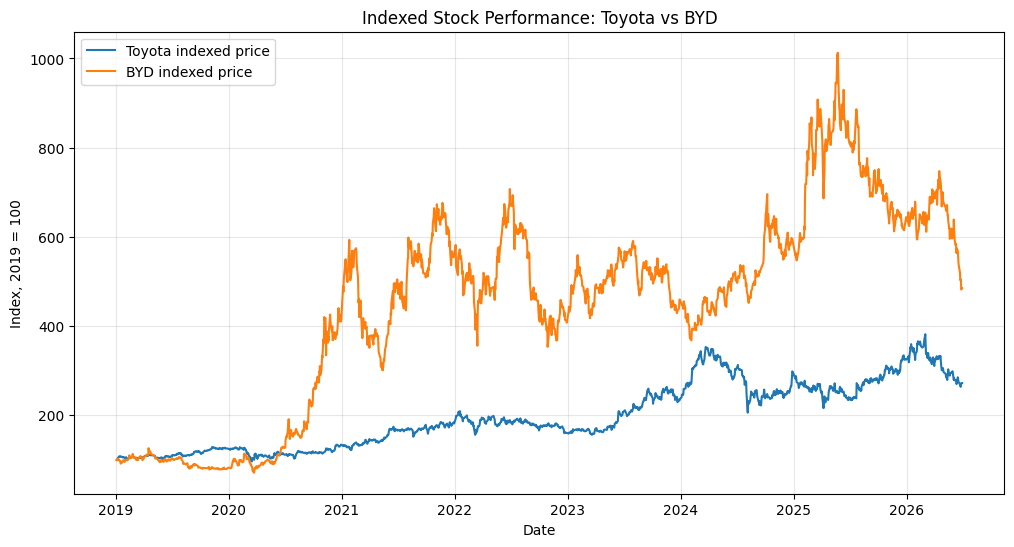

In [4]:
indexed_prices = prices / prices.iloc[0] * 100

plt.figure(figsize=(12, 6))
plt.plot(indexed_prices.index, indexed_prices["Toyota"], label="Toyota indexed price")
plt.plot(indexed_prices.index, indexed_prices["BYD"], label="BYD indexed price")

plt.title("Indexed Stock Performance: Toyota vs BYD")
plt.xlabel("Date")
plt.ylabel("Index, 2019 = 100")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [5]:
returns = np.log(prices / prices.shift(1)).dropna()

annual_mu = returns.mean() * 252
annual_sigma = returns.std() * np.sqrt(252)
corr_matrix = returns.corr()

summary = pd.DataFrame({
    "Annualized Drift": annual_mu,
    "Annualized Volatility": annual_sigma
})

summary

,Annualized Drift,Annualized Volatility
Ticker,,
BYD,0.231354,0.508275
Toyota,0.146830,0.300065


In [6]:
corr_matrix

Ticker,BYD,Toyota
Ticker,,
BYD,1.000000,0.166675
Toyota,0.166675,1.000000


The drift represents the average direction of returns. The volatility represents how unstable or risky the stock has been. The correlation matrix shows how similarly Toyota and BYD have moved historically.

These historical values become the baseline of the Monte Carlo model. The scenario engine then adjusts them based on Thailand-specific policy and macroeconomic shocks.

## Contextualising Thailand's EV Market

Thailand's EV policy matters because it changes the competitive structure of the auto market. Japanese automakers historically dominated Thailand's combustion-engine and hybrid market, while Chinese EV firms gained momentum through affordable BEVs, subsidies, and local factory investment. This notebook uses stock prices for Toyota and BYD as financial proxies for the broader Japan-versus-China auto transition.

## Scenario Design

The model tests three possible futures:

### Scenario A: 30@30 Achieved
Thailand successfully grows domestic EV production. Chinese EV makers benefit from localization, battery investment, and policy support.

### Scenario B: Japanese Hybrid Counter-Attack
EV adoption slows because of insurance costs, charging concerns, and rural infrastructure gaps. Toyota benefits from hybrid demand.

### Scenario C: Macro Stagnation
High household debt weakens auto-loan approvals and drags down total vehicle sales. Both Toyota and BYD face higher uncertainty and weaker returns.

In [7]:
SCENARIOS = {
    "30@30 Achieved": {
        "alpha": {
            "Toyota": -0.01,
            "BYD": 0.05
        },
        "vol_mult": {
            "Toyota": 1.05,
            "BYD": 1.20
        },
        "factor_means": {
            "subsidy_support": 0.03,
            "debt_pressure": -0.005,
            "grid_confidence": 0.015,
            "hybrid_comeback": -0.005
        }
    },

    "Japanese Hybrid Counter-Attack": {
        "alpha": {
            "Toyota": 0.04,
            "BYD": -0.005
        },
        "vol_mult": {
            "Toyota": 1.10,
            "BYD": 1.30
        },
        "factor_means": {
            "subsidy_support": -0.005,
            "debt_pressure": -0.005,
            "grid_confidence": -0.005,
            "hybrid_comeback": 0.035
        }
    },

    "Macro Stagnation": {
        "alpha": {
            "Toyota": -0.04,
            "BYD": -0.05
        },
        "vol_mult": {
            "Toyota": 1.40,
            "BYD": 1.60
        },
        "factor_means": {
            "subsidy_support": -0.01,
            "debt_pressure": -0.04,
            "grid_confidence": -0.01,
            "hybrid_comeback": 0.005
        }
    }
}

The alpha values are scenario-specific return adjustments. For example, in the 30@30 scenario, BYD receives a positive drift adjustment because Chinese EV firms are assumed to benefit from Thai EV localization. Toyota receives a slight negative adjustment because pure EV competition pressures legacy combustion-engine business models.

The volatility multipliers increase or reduce uncertainty. BYD receives higher volatility because it is more exposed to policy, competition, and EV adoption uncertainty.

In [8]:
FACTOR_BETAS = {
    "Toyota": {
        "subsidy_support": -0.20,
        "debt_pressure": 0.70,
        "grid_confidence": -0.10,
        "hybrid_comeback": 0.90
    },
    "BYD": {
        "subsidy_support": 0.90,
        "debt_pressure": 0.80,
        "grid_confidence": 0.50,
        "hybrid_comeback": -0.60
    }
}

FACTOR_STDS = {
    "subsidy_support": 0.03,
    "debt_pressure": 0.025,
    "grid_confidence": 0.02,
    "hybrid_comeback": 0.025
}

BYD is assumed to benefit more from EV subsidy support and grid-cleanliness confidence. Toyota is assumed to benefit more from a hybrid comeback. Both companies are hurt by debt pressure because high household debt can reduce auto-loan approvals and weaken vehicle demand.

In [9]:
def run_factor_monte_carlo(
    start_prices,
    annual_mu,
    annual_sigma,
    corr_matrix,
    scenario_params,
    years=5,
    steps_per_year=252,
    n_sims=10_000,
    seed=42
):
    rng = np.random.default_rng(seed)

    assets = list(start_prices.index)
    n_assets = len(assets)
    n_steps = years * steps_per_year
    dt = 1 / steps_per_year

    paths = np.zeros((n_sims, n_steps + 1, n_assets))
    paths[:, 0, :] = start_prices.values

    corr = corr_matrix.loc[assets, assets].values
    chol = np.linalg.cholesky(corr)

    base_mu = annual_mu.loc[assets].values
    base_sigma = annual_sigma.loc[assets].values

    vol_mult = np.array([
        scenario_params["vol_mult"][asset] for asset in assets
    ])

    adjusted_sigma = base_sigma * vol_mult

    alpha = np.array([
        scenario_params["alpha"][asset] for asset in assets
    ])

    current_mu = np.tile(base_mu + alpha, (n_sims, 1))

    for t in range(1, n_steps + 1):

        # Resample macro factors once per simulated year
        if t == 1 or t % steps_per_year == 0:
            factor_values = {}

            for factor, mean_value in scenario_params["factor_means"].items():
                factor_values[factor] = rng.normal(
                    loc=mean_value,
                    scale=FACTOR_STDS[factor],
                    size=n_sims
                )

            current_mu = np.tile(base_mu + alpha, (n_sims, 1))

            for asset_index, asset in enumerate(assets):
                factor_impact = np.zeros(n_sims)

                for factor, beta in FACTOR_BETAS[asset].items():
                    factor_impact += beta * factor_values[factor]

                current_mu[:, asset_index] += factor_impact

        z = rng.normal(size=(n_sims, n_assets))
        correlated_z = z @ chol.T

        daily_returns = (
            (current_mu - 0.5 * adjusted_sigma ** 2) * dt
            + adjusted_sigma * np.sqrt(dt) * correlated_z
        )

        paths[:, t, :] = paths[:, t - 1, :] * np.exp(daily_returns)

    return paths

1. Starts with the latest Toyota and BYD prices
2. Uses historical return and volatility as baseline values
3. Adjusts return and volatility depending on the scenario
4. Randomly samples macro shocks each year
5. Simulates 10,000 possible future price paths
6. Repeats this over 5 years

In [10]:
YEARS = 5
N_SIMS = 10_000

start_prices = prices.iloc[-1]

simulation_results = {}

for scenario_name, scenario_params in SCENARIOS.items():
    paths = run_factor_monte_carlo(
        start_prices=start_prices,
        annual_mu=annual_mu,
        annual_sigma=annual_sigma,
        corr_matrix=corr_matrix,
        scenario_params=scenario_params,
        years=YEARS,
        n_sims=N_SIMS,
        seed=SEED
    )

    simulation_results[scenario_name] = paths

print("Simulation complete.")

Simulation complete.


In [11]:
def calculate_risk_metrics(paths, start_prices, scenario_name):
    assets = list(start_prices.index)

    terminal_prices = paths[:, -1, :]
    total_returns = terminal_prices / start_prices.values - 1

    rows = []

    for i, asset in enumerate(assets):
        asset_returns = total_returns[:, i]

        var_5 = np.percentile(asset_returns, 5)
        es_5 = asset_returns[asset_returns <= var_5].mean()

        median_return = np.percentile(asset_returns, 50)
        upside_95 = np.percentile(asset_returns, 95)

        prob_loss = np.mean(asset_returns < 0)

        rows.append({
            "Scenario": scenario_name,
            "Asset": asset,
            "Median 5Y Return": median_return,
            "5% VaR": var_5,
            "Expected Shortfall": es_5,
            "95th Percentile Upside": upside_95,
            "Probability of Loss": prob_loss
        })

    return pd.DataFrame(rows)


risk_tables = []

for scenario_name, paths in simulation_results.items():
    risk_tables.append(
        calculate_risk_metrics(paths, start_prices, scenario_name)
    )

risk_summary = pd.concat(risk_tables, ignore_index=True)

risk_summary

,Scenario,Asset,Median 5Y Return,5% VaR,Expected Shortfall,95th Percentile Upside,Probability of Loss
0,30@30 Achieved,BYD,0.915718,-0.794055,-0.872312,17.369094,0.3174
1,30@30 Achieved,Toyota,0.441431,-0.556519,-0.662942,3.617186,0.3033
2,Japanese Hybrid Counter-Attack,BYD,-0.108195,-0.920308,-0.952112,9.309913,0.5334
3,Japanese Hybrid Counter-Attack,Toyota,1.265545,-0.342679,-0.504980,6.655068,0.1359
4,Macro Stagnation,BYD,-0.626177,-0.980860,-0.989497,6.625045,0.7063
5,Macro Stagnation,Toyota,-0.001072,-0.792062,-0.853179,3.735680,0.5005


In [12]:
formatted_risk = risk_summary.copy()

percent_cols = [
    "Median 5Y Return",
    "5% VaR",
    "Expected Shortfall",
    "95th Percentile Upside",
    "Probability of Loss"
]

for col in percent_cols:
    formatted_risk[col] = (formatted_risk[col] * 100).round(2).astype(str) + "%"

formatted_risk

,Scenario,Asset,Median 5Y Return,5% VaR,Expected Shortfall,95th Percentile Upside,Probability of Loss
0,30@30 Achieved,BYD,91.57%,-79.41%,-87.23%,1736.91%,31.74%
1,30@30 Achieved,Toyota,44.14%,-55.65%,-66.29%,361.72%,30.33%
2,Japanese Hybrid Counter-Attack,BYD,-10.82%,-92.03%,-95.21%,930.99%,53.34%
3,Japanese Hybrid Counter-Attack,Toyota,126.55%,-34.27%,-50.5%,665.51%,13.59%
4,Macro Stagnation,BYD,-62.62%,-98.09%,-98.95%,662.5%,70.63%
5,Macro Stagnation,Toyota,-0.11%,-79.21%,-85.32%,373.57%,50.05%


VaR shows the loss threshold in the worst 5% of outcomes. Expected Shortfall goes one step further and asks: if the bad 5% outcome happens, how bad is the average loss inside that tail?

This is useful because two stocks can have similar average outcomes but very different downside risks.

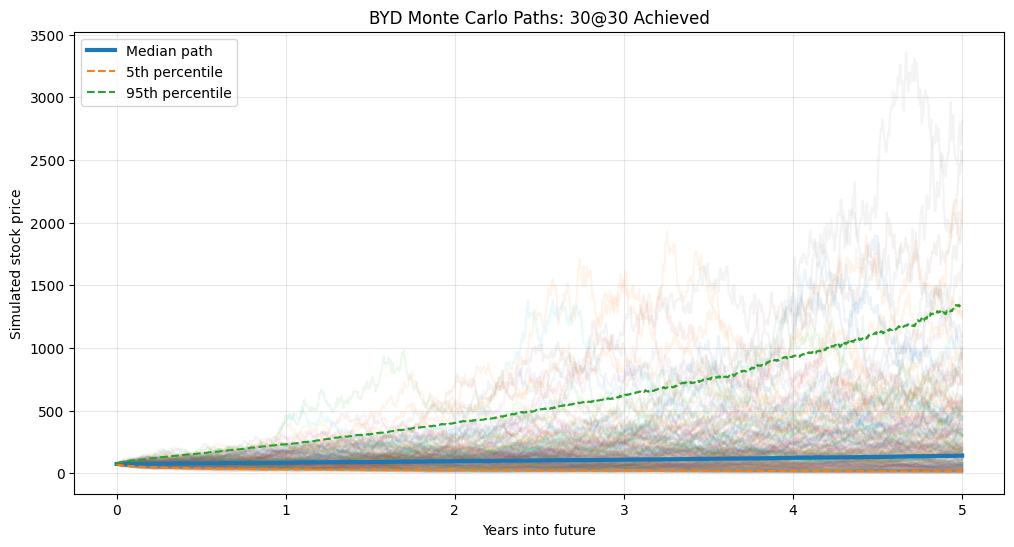

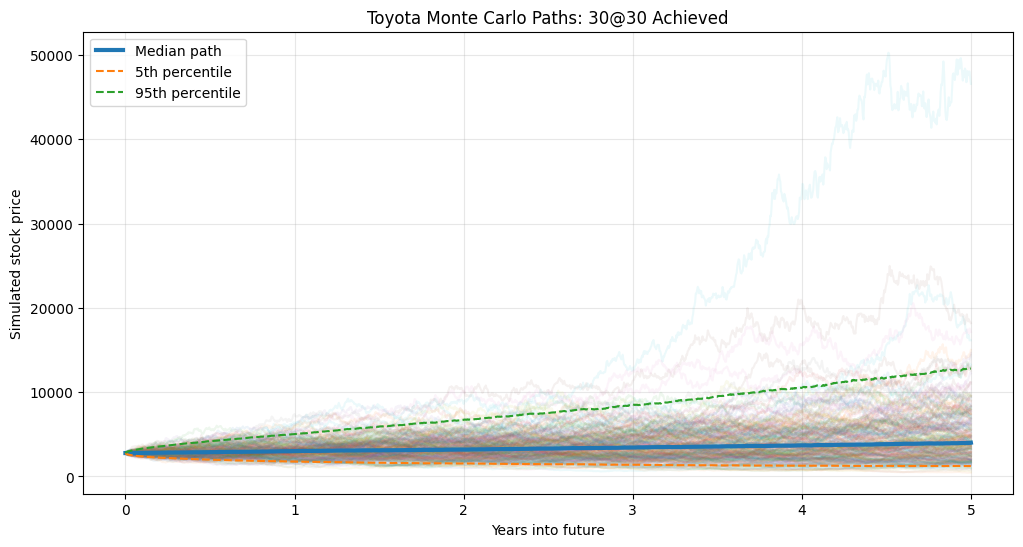

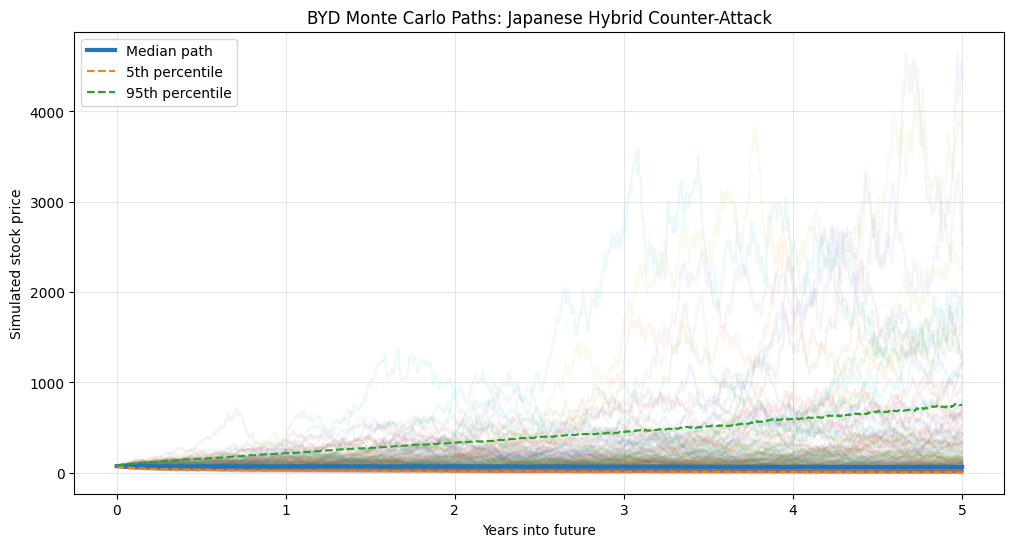

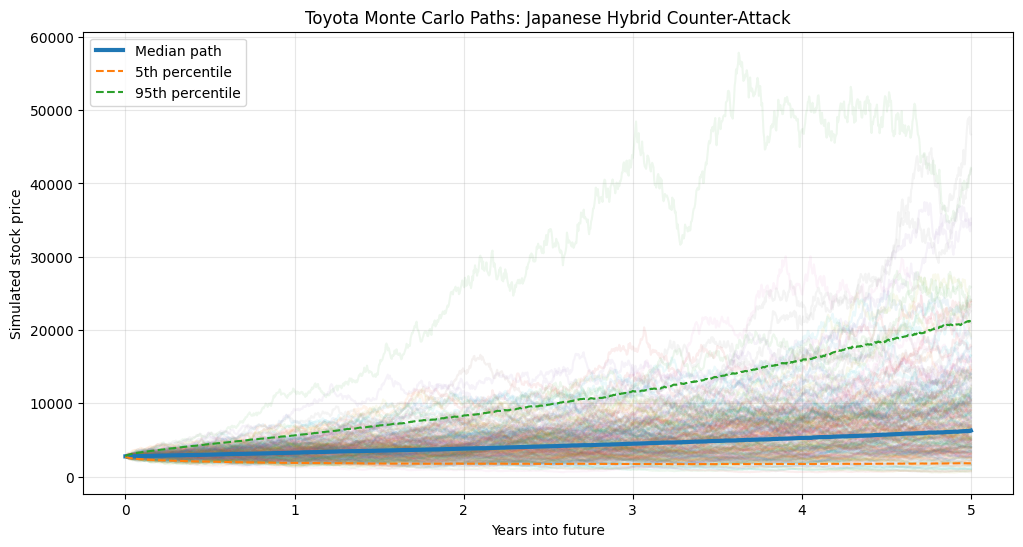

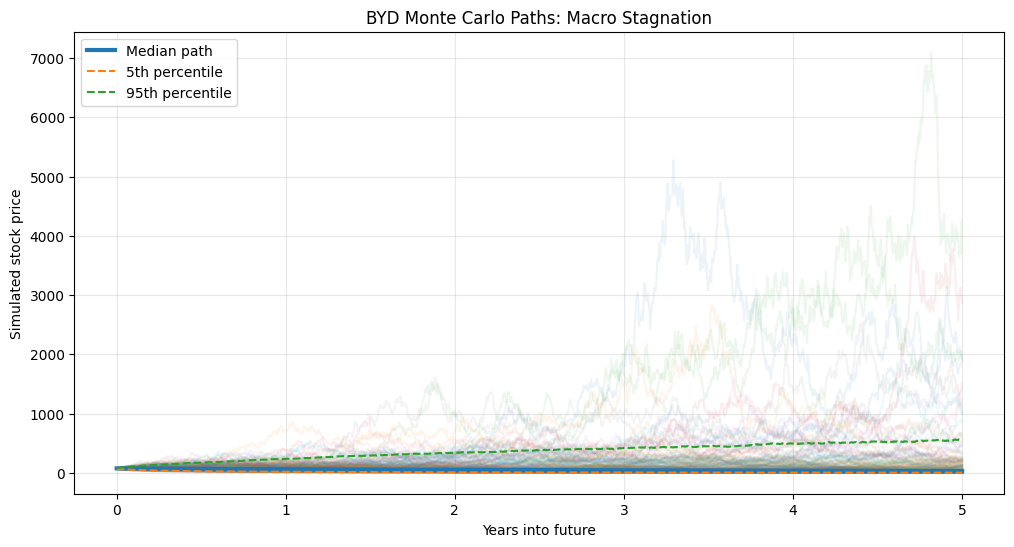

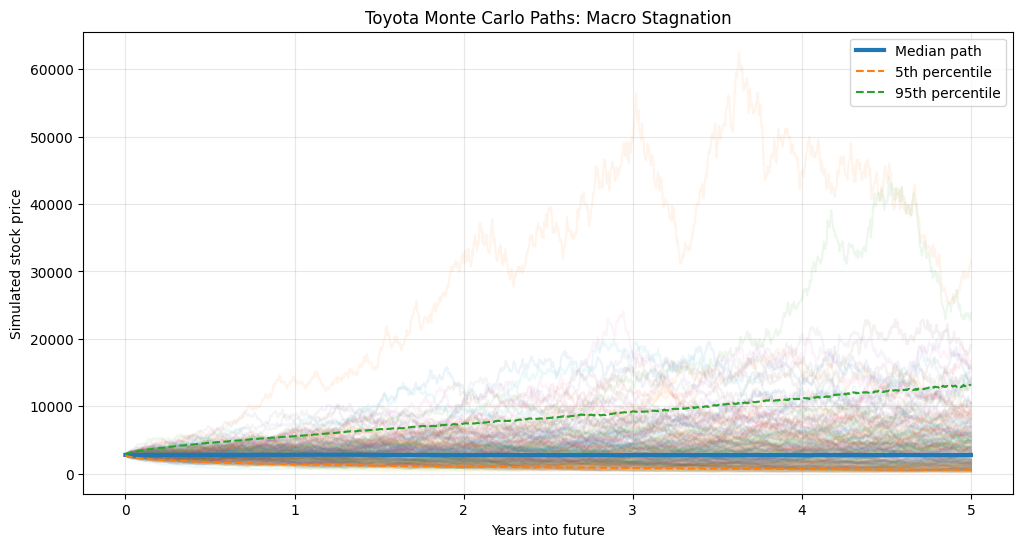

In [13]:
def plot_spaghetti(paths, scenario_name, asset_names, n_lines=250):
    time_axis = np.arange(paths.shape[1]) / 252

    for asset_index, asset in enumerate(asset_names):
        plt.figure(figsize=(12, 6))

        sample_indices = rng.choice(paths.shape[0], size=n_lines, replace=False)

        for idx in sample_indices:
            plt.plot(time_axis, paths[idx, :, asset_index], alpha=0.08)

        median_path = np.median(paths[:, :, asset_index], axis=0)
        p5_path = np.percentile(paths[:, :, asset_index], 5, axis=0)
        p95_path = np.percentile(paths[:, :, asset_index], 95, axis=0)

        plt.plot(time_axis, median_path, linewidth=3, label="Median path")
        plt.plot(time_axis, p5_path, linestyle="--", label="5th percentile")
        plt.plot(time_axis, p95_path, linestyle="--", label="95th percentile")

        plt.title(f"{asset} Monte Carlo Paths: {scenario_name}")
        plt.xlabel("Years into future")
        plt.ylabel("Simulated stock price")
        plt.legend()
        plt.grid(alpha=0.3)
        plt.show()


asset_names = list(start_prices.index)

for scenario_name, paths in simulation_results.items():
    plot_spaghetti(paths, scenario_name, asset_names)

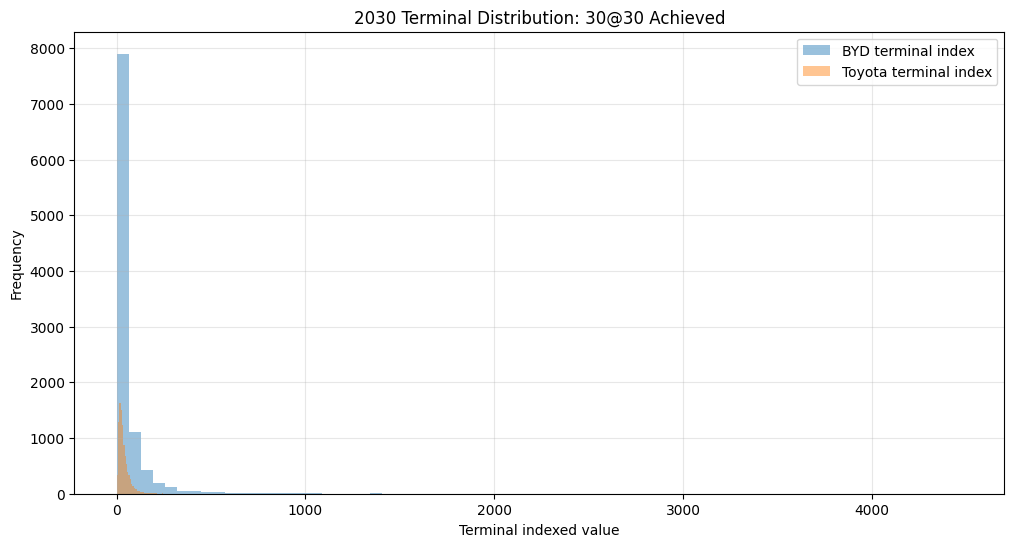

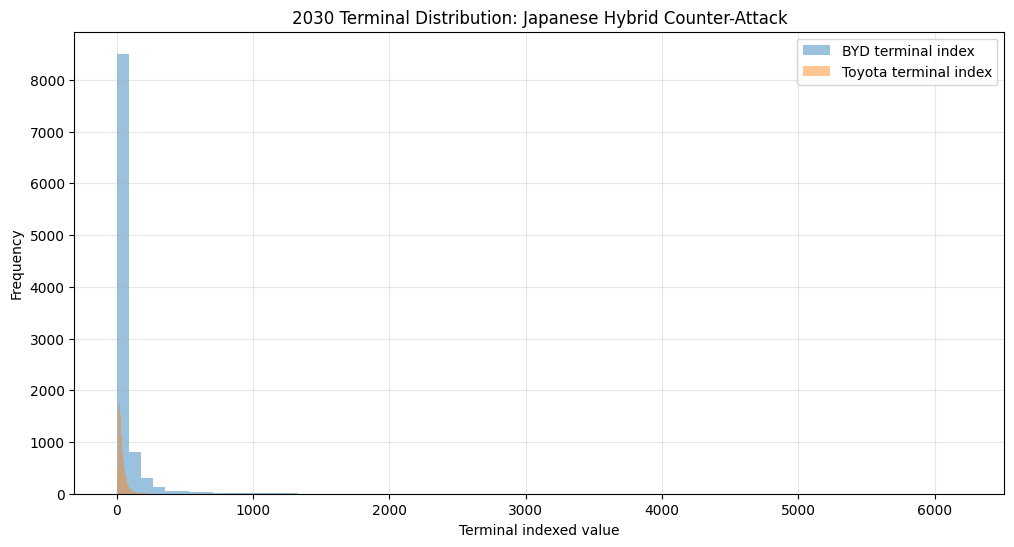

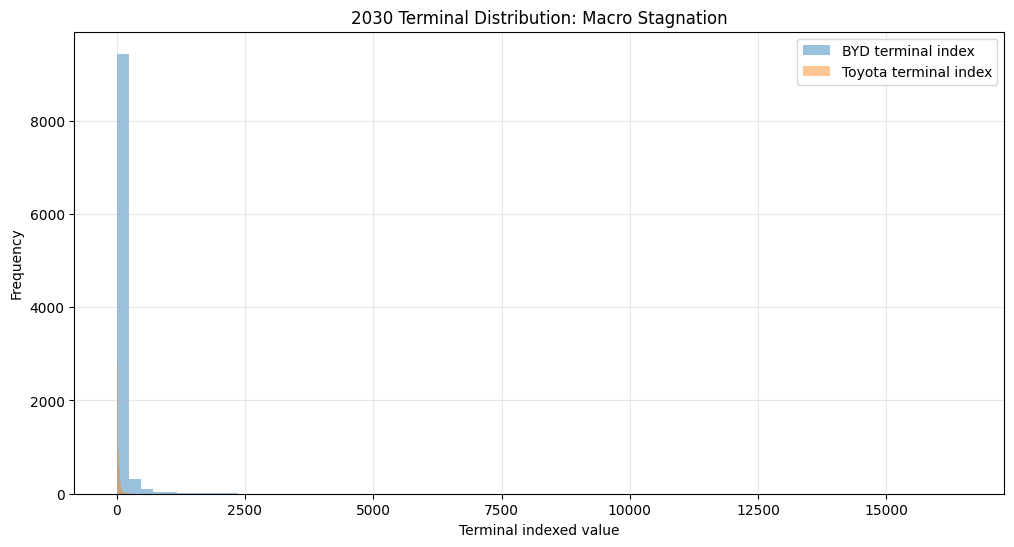

In [14]:
def plot_terminal_distribution(paths, scenario_name, asset_names):
    terminal_prices = paths[:, -1, :]

    plt.figure(figsize=(12, 6))

    for asset_index, asset in enumerate(asset_names):
        terminal_indexed = terminal_prices[:, asset_index] / terminal_prices[0, asset_index] * 100
        plt.hist(
            terminal_indexed,
            bins=70,
            alpha=0.45,
            label=f"{asset} terminal index"
        )

    plt.title(f"2030 Terminal Distribution: {scenario_name}")
    plt.xlabel("Terminal indexed value")
    plt.ylabel("Frequency")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


for scenario_name, paths in simulation_results.items():
    plot_terminal_distribution(paths, scenario_name, asset_names)

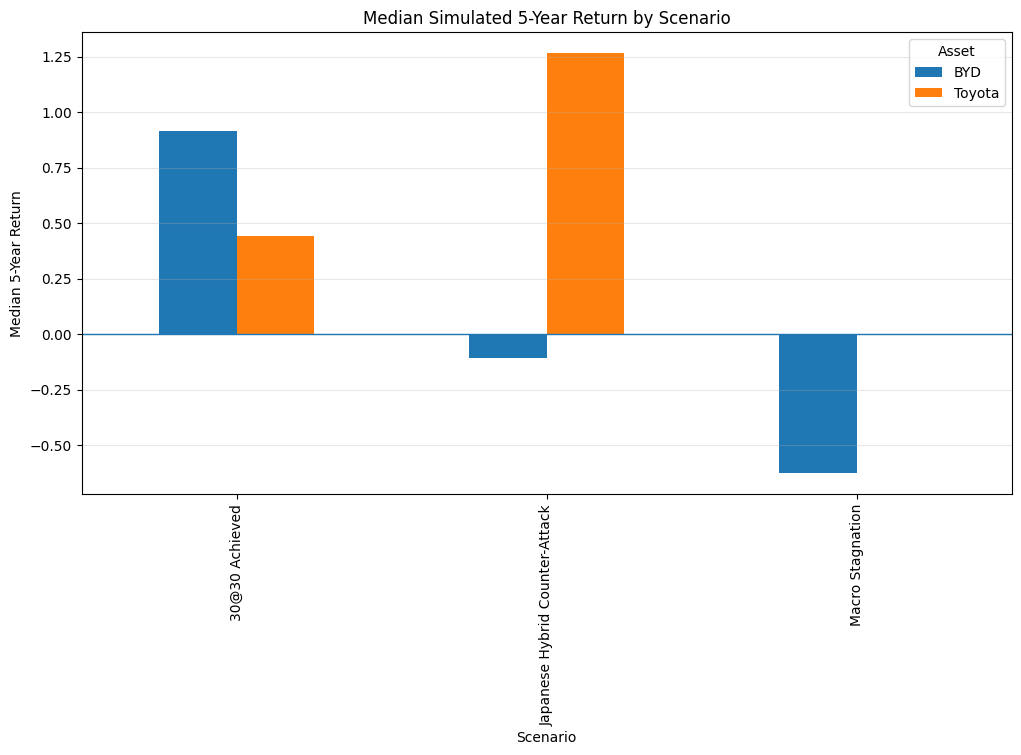

In [15]:
comparison = risk_summary.pivot(
    index="Scenario",
    columns="Asset",
    values="Median 5Y Return"
)

comparison.plot(kind="bar", figsize=(12, 6))

plt.title("Median Simulated 5-Year Return by Scenario")
plt.xlabel("Scenario")
plt.ylabel("Median 5-Year Return")
plt.axhline(0, linewidth=1)
plt.grid(axis="y", alpha=0.3)
plt.show()

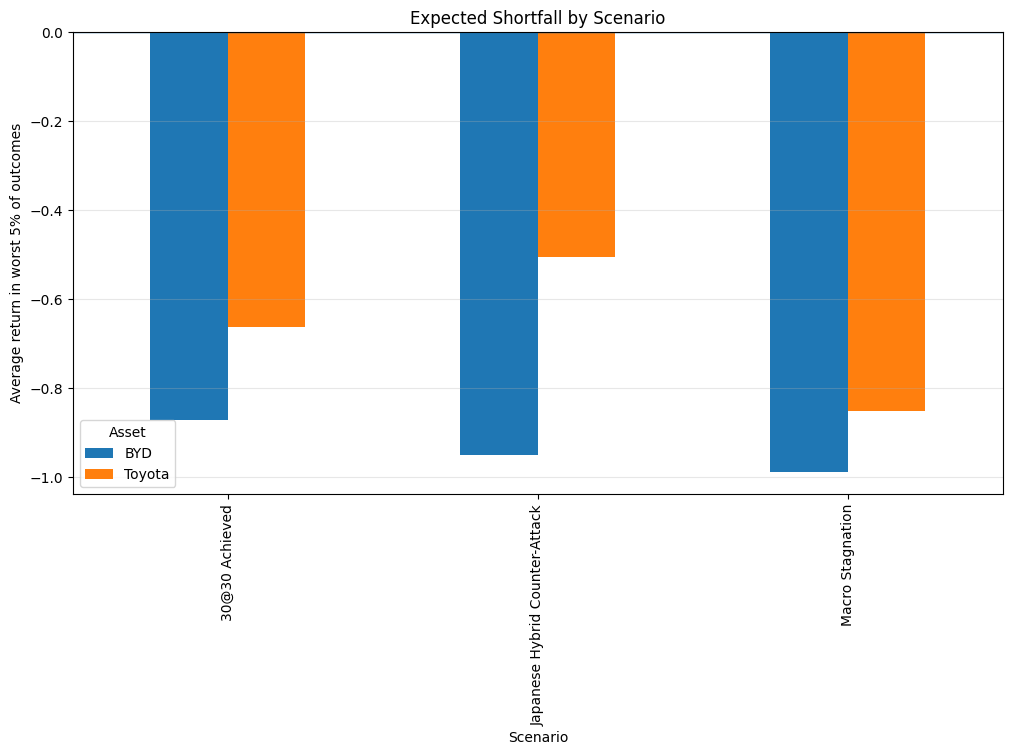

In [16]:
downside = risk_summary.pivot(
    index="Scenario",
    columns="Asset",
    values="Expected Shortfall"
)

downside.plot(kind="bar", figsize=(12, 6))

plt.title("Expected Shortfall by Scenario")
plt.xlabel("Scenario")
plt.ylabel("Average return in worst 5% of outcomes")
plt.axhline(0, linewidth=1)
plt.grid(axis="y", alpha=0.3)
plt.show()

## Conclusion

In the 30@30 Achieved scenario, BYD benefits from stronger EV adoption, local production, and continued policy support. However, this upside comes with higher volatility because BYD is more exposed to subsidy deadlines, battery supply chains, and competitive pricing pressure.

In the Japanese Hybrid Counter-Attack scenario, Toyota performs better because hybrids become a safer middle ground for consumers who are not fully ready to switch to EVs. This scenario reflects the possibility that charging anxiety, insurance costs, and rural infrastructure slow down BEV adoption.

In the Macro Stagnation scenario, both firms suffer because Thailand's high household debt weakens vehicle affordability and auto-loan approvals. In this case, the main risk is not whether consumers prefer EVs or hybrids. The bigger risk is whether consumers can afford new vehicles at all.

Overall, this notebook shows how Monte Carlo simulation can be expanded beyond historical stock volatility. By adding policy and macroeconomic shocks, the model becomes a tool for testing economic narratives under uncertainty.

## Limitations

1. This notebook is a scenario simulation, not a stock-price prediction model. The factor sensitivities are assumptions based on economic reasoning not estimated causal coefficients.

2. The model also uses Toyota and BYD as proxy firms for broader automotive factions. Their stock prices are affected by many factors outside Thailand, including global demand, exchange rates, supply chains, tariffs, etc.

3. A stronger future version could add Thai vehicle registration data, exchange-rate effects, battery price data, auto-loan approval rates, and company revenue exposure by region.

4. This notebook uses real historical stock-price data for Toyota and BYD through `yfinance`. These scenario parameters are assumptions, not directly measured coefficients. Therefore, the notebook should be interpreted as a policy-shock simulation rather than a prediction model. A future version could improve the model by adding real Thai vehicle registration data, EV market-share data, auto-loan approval rates, and battery-price data.